In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score


from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import ConfusionMatrixDisplay


RANDOM_STATE = 42

In [2]:
# Load dataset
df = pd.read_csv("student-por.csv", sep=";")

In [3]:
# Exporing the dataset
df.shape
df.head()
df.info()
df.describe()
df.isna().sum()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  
 10  reason      649 non-null    str  
 11  guardian    649 non-null    str  
 12  traveltime  649 non-null    int64
 13  studytime   649 non-null    int64
 14  failures    649 non-null    int64
 15  schoolsup   649 non-null    str  
 16  famsup      649 non-null    str  
 17  paid        649 non-null    str  
 18  activities  649 non-null    str  
 19  nursery     649 non-null    str  
 20  higher      649 non-null    str  
 21  inte

np.int64(0)

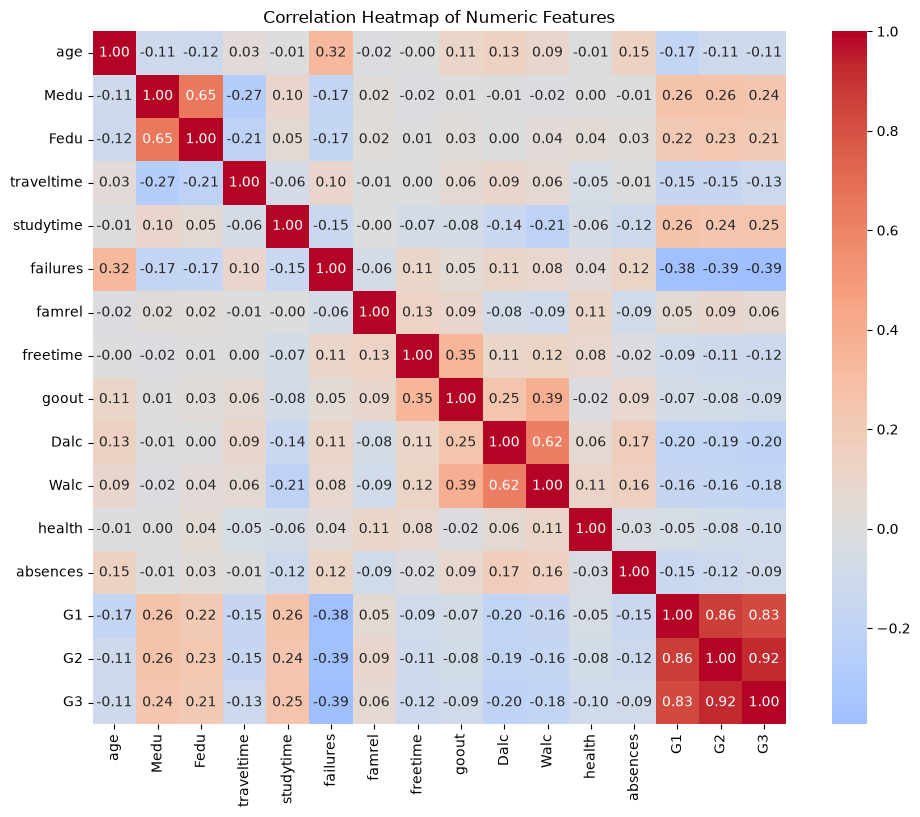

In [4]:
# Visualizing the correlation heatmap of numeric features
numeric_cols = ['age','Medu','Fedu','traveltime','studytime','failures',
                 'famrel','freetime','goout','Dalc','Walc','health','absences','G1','G2','G3']

plt.figure(figsize=(12, 9))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

In [5]:
# Creating a new column called risk level for the prediction
def risk_level(g3):
    if g3 <= 9:
        return "High"
    elif g3 <= 14:
        return "Medium"
    else:
        return "Low"

df["Risk_level"] = df["G3"].apply(risk_level)

/var/folders/yl/7gr7dmf56790rqkv1h1lrhb40000gn/T/ipykernel_29220/154384405.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Risk_level", order=["Low", "Medium", "High"], palette="viridis")


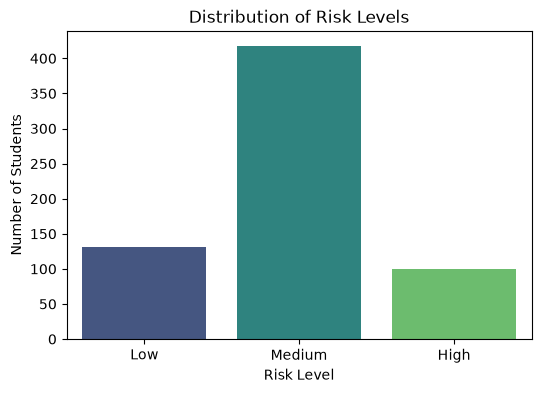

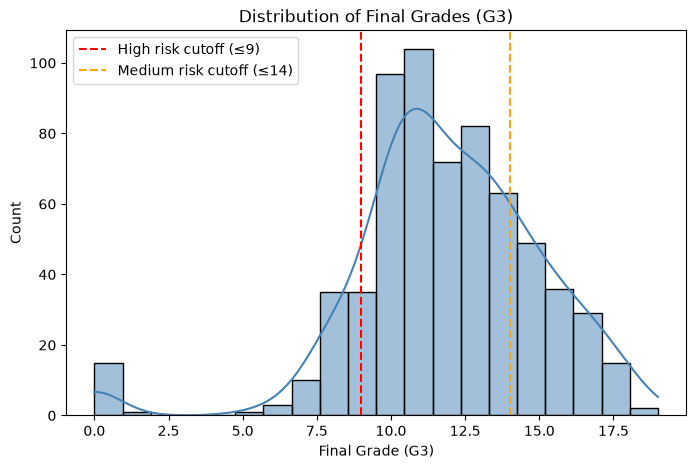

/var/folders/yl/7gr7dmf56790rqkv1h1lrhb40000gn/T/ipykernel_29220/154384405.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Risk_level", y="studytime", order=["Low","Medium","High"], ax=axes[0], palette="Set2")
/var/folders/yl/7gr7dmf56790rqkv1h1lrhb40000gn/T/ipykernel_29220/154384405.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Risk_level", y="absences", order=["Low","Medium","High"], ax=axes[1], palette="Set2")
/var/folders/yl/7gr7dmf56790rqkv1h1lrhb40000gn/T/ipykernel_29220/154384405.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` fo

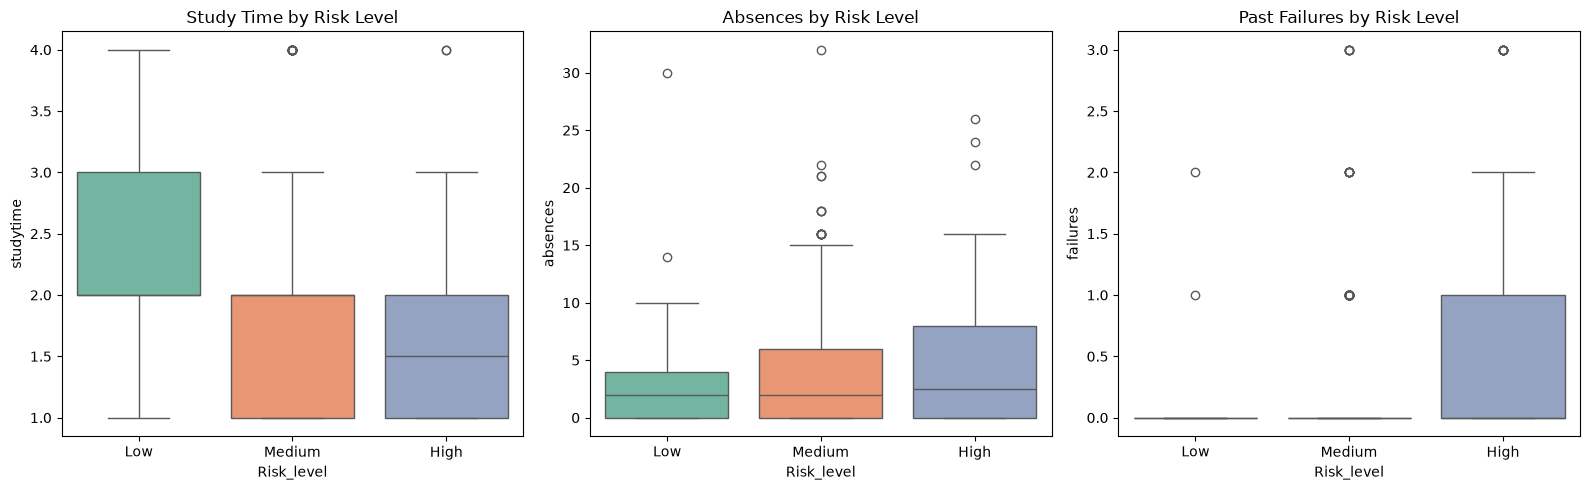

In [6]:
# Visualizing the distribution of risk levels
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Risk_level", order=["Low", "Medium", "High"], palette="viridis")
plt.title("Distribution of Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Number of Students")
plt.show()
# Visualizing the distribution of final grades (G3)
plt.figure(figsize=(8, 5))
sns.histplot(df["G3"], bins=20, kde=True, color="steelblue")
plt.axvline(9, color="red", linestyle="--", label="High risk cutoff (≤9)")
plt.axvline(14, color="orange", linestyle="--", label="Medium risk cutoff (≤14)")
plt.title("Distribution of Final Grades (G3)")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Count")
plt.legend()
plt.show()

# Visualizing the relationship between risk level and study time, absences, and past failures
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df, x="Risk_level", y="studytime", order=["Low","Medium","High"], ax=axes[0], palette="Set2")
axes[0].set_title("Study Time by Risk Level")

sns.boxplot(data=df, x="Risk_level", y="absences", order=["Low","Medium","High"], ax=axes[1], palette="Set2")
axes[1].set_title("Absences by Risk Level")

sns.boxplot(data=df, x="Risk_level", y="failures", order=["Low","Medium","High"], ax=axes[2], palette="Set2")
axes[2].set_title("Past Failures by Risk Level")

plt.tight_layout()
plt.show()

In [7]:
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 34 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  
 10  reason      649 non-null    str  
 11  guardian    649 non-null    str  
 12  traveltime  649 non-null    int64
 13  studytime   649 non-null    int64
 14  failures    649 non-null    int64
 15  schoolsup   649 non-null    str  
 16  famsup      649 non-null    str  
 17  paid        649 non-null    str  
 18  activities  649 non-null    str  
 19  nursery     649 non-null    str  
 20  higher      649 non-null    str  
 21  inte

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


In [8]:
# Seperating and Targeting
X = df.drop(['G2','G3', 'Risk_level'], axis=1)
y = df['Risk_level']

In [9]:
# Splitting the data
X_train, X_temp, y_train, y_temp = train_test_split(
    X, 
    y, 
    test_size=0.3, 
    random_state= RANDOM_STATE, 
    stratify=y
    )


X_val, X_test, y_val, y_test = train_test_split(
    X_temp, 
    y_temp, 
    test_size=0.5, 
    random_state=RANDOM_STATE, 
    stratify=y_temp
    )

In [10]:
# Encoding the features

# Binary Encoding
encoder = LabelEncoder()

binary_features = [
    'school',
    'sex',
    'address',
    'famsize',
    'Pstatus',
    'schoolsup',
    'famsup',
    'paid',
    'activities',
    'nursery',
    'higher',
    'internet',
    'romantic'
]

for col in binary_features:
    X_train[col] = encoder.fit_transform(X_train[col])
    X_val[col] = encoder.transform(X_val[col])
    X_test[col] = encoder.transform(X_test[col])


# OneHot Encoding
categorical_features = [
    'Mjob',
    'Fjob',
    'reason',
    'guardian'
    ]

enc = OneHotEncoder(drop='first', sparse_output=False)
train_cat = enc.fit_transform(X_train[categorical_features])
val_cat = enc.transform(X_val[categorical_features])
test_cat = enc.transform(X_test[categorical_features])

# Converting them to Dataframes
cat_names = enc.get_feature_names_out(categorical_features)

train_cat = pd.DataFrame(
    train_cat, columns= cat_names,index= X_train.index
)

val_cat = pd.DataFrame(
    val_cat, columns= cat_names, index= X_val.index
)

test_cat = pd.DataFrame(
    test_cat, columns= cat_names, index= X_test.index
)



# StandardScaler Encoding
numeric_features = [
    'age',
    'Medu',
    'Fedu',
    'traveltime',
    'studytime',
    'failures',
    'famrel',
    'freetime',
    'goout',
    'Dalc',
    'Walc',
    'health',
    'absences',
    'G1'
    ]

scaler = StandardScaler()
train_num = scaler.fit_transform(X_train[numeric_features])
val_num = scaler.transform(X_val[numeric_features])
test_num = scaler.transform(X_test[numeric_features])


# Converting them to Dataframes
train_num = pd.DataFrame(
    train_num, columns= numeric_features, index=X_train.index
)

val_num = pd.DataFrame(
    val_num, columns=numeric_features, index=X_val.index
)

test_num = pd.DataFrame(
    test_num, columns=numeric_features, index=X_test.index
)

In [11]:
# Combining processed data

# Combining the Training Data
X_train_processed = pd.concat([
    X_train[binary_features],
    train_cat,
    train_num
], axis=1)


# Combining the Validation Data
X_val_processed = pd.concat([
    X_val[binary_features],
    val_cat,
    val_num
], axis=1)

# Combining the Testing Data
X_test_processed = pd.concat([
    X_test[binary_features],
    test_cat,
    test_num
], axis=1)

In [12]:
X_test_processed.info()
print(X_train.columns.tolist())

<class 'pandas.DataFrame'>
Index: 98 entries, 578 to 44
Data columns (total 40 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   school             98 non-null     int64  
 1   sex                98 non-null     int64  
 2   address            98 non-null     int64  
 3   famsize            98 non-null     int64  
 4   Pstatus            98 non-null     int64  
 5   schoolsup          98 non-null     int64  
 6   famsup             98 non-null     int64  
 7   paid               98 non-null     int64  
 8   activities         98 non-null     int64  
 9   nursery            98 non-null     int64  
 10  higher             98 non-null     int64  
 11  internet           98 non-null     int64  
 12  romantic           98 non-null     int64  
 13  Mjob_health        98 non-null     float64
 14  Mjob_other         98 non-null     float64
 15  Mjob_services      98 non-null     float64
 16  Mjob_teacher       98 non-null     float64

In [13]:
print("Training:", X_train_processed.shape)
print("Validation:", X_val_processed.shape)
print("Testing:", X_test_processed.shape)

X_train_processed.head()
X_val_processed.head()
X_test_processed.head()

Training: (454, 40)
Validation: (97, 40)
Testing: (98, 40)


,school,sex,address,famsize,Pstatus,schoolsup,famsup,paid,activities,nursery,...,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1
578,1,1,1,0,1,0,1,0,0,1,...,0.063290,1.209317,0.095345,1.709899,0.660956,0.604501,0.593293,-0.370588,0.081095,-1.249625
586,1,0,1,0,1,1,1,0,1,1,...,0.063290,-0.377475,1.151122,1.709899,1.506236,-0.529563,0.593293,1.008485,-0.790312,-1.249625
443,1,1,0,1,1,0,1,0,1,1,...,0.063290,-0.377475,1.151122,-0.149488,0.660956,-0.529563,-0.198928,-1.060124,0.734649,-1.614233
38,0,0,0,0,1,1,1,0,1,1,...,1.260534,-0.377475,0.095345,-0.149488,-1.029602,-0.529563,-0.991149,1.008485,-0.354609,-0.155802
547,1,1,0,1,1,0,0,0,0,1,...,-1.133953,-0.377475,0.095345,-2.008876,-1.029602,0.604501,-0.991149,-1.060124,-0.790312,-0.520410


In [45]:
# Create model
lr_model = LogisticRegression(random_state=42, max_iter=1000)

# Train model
lr_model.fit(X_train_processed, y_train)

# Validation predictions
y_val_pred_lr = lr_model.predict(X_val_processed)

# Accuracy
lr_accuracy = accuracy_score(y_val, y_val_pred_lr)

print("Validation Accuracy:", lr_accuracy)

print("\nClassification Report")
print(classification_report(y_val, y_val_pred_lr))

print("\nConfusion Matrix")
print(confusion_matrix(y_val, y_val_pred_lr, labels=["Low", "Medium", "High"]))

Validation Accuracy: 0.7835051546391752

Classification Report
              precision    recall  f1-score   support

        High       0.67      0.67      0.67        15
         Low       0.75      0.63      0.69        19
      Medium       0.82      0.86      0.84        63

    accuracy                           0.78        97
   macro avg       0.74      0.72      0.73        97
weighted avg       0.78      0.78      0.78        97


Confusion Matrix
[[12  7  0]
 [ 4 54  5]
 [ 0  5 10]]


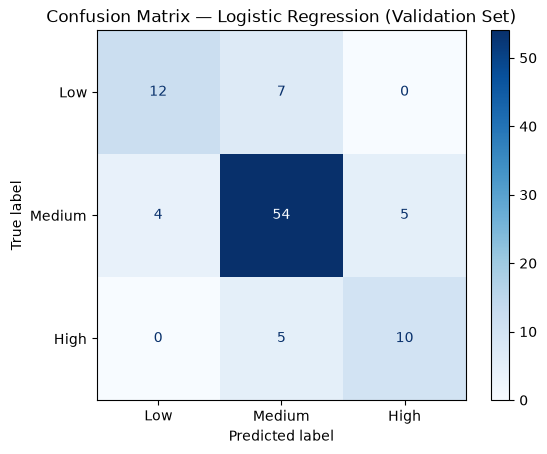

In [46]:
cm_lr = confusion_matrix(y_val, y_val_pred_lr, labels=["Low", "Medium", "High"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=["Low", "Medium", "High"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — Logistic Regression (Validation Set)")
plt.show()

In [44]:
# Create model
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

# Train
dt_model.fit(X_train_processed, y_train)

# Predict
y_val_pred_dt = dt_model.predict(X_val_processed)

# Accuracy
dt_accuracy = accuracy_score(y_val, y_val_pred_dt)

print("Validation Accuracy:", dt_accuracy)

print("\nClassification Report")
print(classification_report(y_val, y_val_pred_dt))

print("\nConfusion Matrix")
print(confusion_matrix(y_val, y_val_pred_dt, labels=["Low", "Medium", "High"]))



Validation Accuracy: 0.7835051546391752

Classification Report
              precision    recall  f1-score   support

        High       0.59      0.67      0.62        15
         Low       0.81      0.68      0.74        19
      Medium       0.83      0.84      0.83        63

    accuracy                           0.78        97
   macro avg       0.74      0.73      0.73        97
weighted avg       0.79      0.78      0.78        97


Confusion Matrix
[[13  6  0]
 [ 3 53  7]
 [ 0  5 10]]


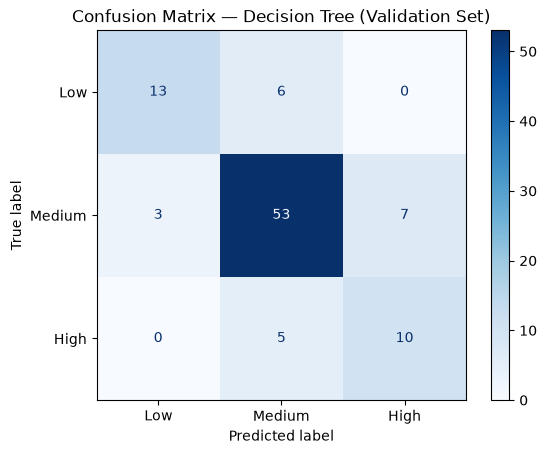

In [48]:
cm_dt = confusion_matrix(y_val, y_val_pred_dt, labels=["Low", "Medium", "High"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=["Low", "Medium", "High"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — Decision Tree (Validation Set)")
plt.show()

In [43]:
# Create model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train
rf_model.fit(X_train_processed, y_train)

# Predict
y_val_pred_rf = rf_model.predict(X_val_processed)

# Accuracy
rf_accuracy = accuracy_score(y_val, y_val_pred_rf)

print("Validation Accuracy:", rf_accuracy)

print("\nClassification Report")
print(classification_report(y_val, y_val_pred_rf))

print("\nConfusion Matrix")
print(confusion_matrix(y_val, y_val_pred_rf, labels=["Low", "Medium", "High"]))

Validation Accuracy: 0.7835051546391752

Classification Report
              precision    recall  f1-score   support

        High       0.75      0.40      0.52        15
         Low       0.76      0.68      0.72        19
      Medium       0.79      0.90      0.84        63

    accuracy                           0.78        97
   macro avg       0.77      0.66      0.70        97
weighted avg       0.78      0.78      0.77        97


Confusion Matrix
[[13  6  0]
 [ 4 57  2]
 [ 0  9  6]]


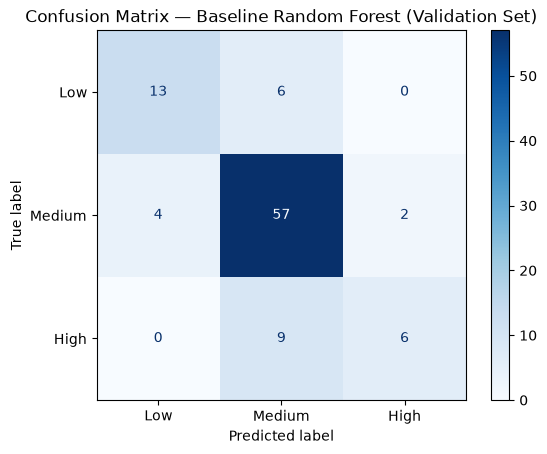

In [50]:
cm_rf = confusion_matrix(y_val, y_val_pred_rf, labels=["Low", "Medium", "High"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Low", "Medium", "High"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — Baseline Random Forest (Validation Set)")
plt.show()

In [17]:
results = {
    "Logistic Regression": lr_accuracy,
    "Decision Tree": dt_accuracy,
    "Random Forest": rf_accuracy
}

for model, score in results.items():
    print(f"{model}: {score:.4f}")

Logistic Regression: 0.7835
Decision Tree: 0.7835
Random Forest: 0.7835


In [18]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_val, y_val_pred_lr),
        accuracy_score(y_val, y_val_pred_dt),
        accuracy_score(y_val, y_val_pred_rf)
    ],
    "Macro F1": [
        f1_score(y_val, y_val_pred_lr, average="macro"),
        f1_score(y_val, y_val_pred_dt, average="macro"),
        f1_score(y_val, y_val_pred_rf, average="macro")
    ],
    "Precision": [
        precision_score(y_val, y_val_pred_lr, average="weighted"),
        precision_score(y_val, y_val_pred_dt, average="weighted"),
        precision_score(y_val, y_val_pred_rf, average="weighted")
    ],
    "Recall": [
        recall_score(y_val, y_val_pred_lr, average="weighted"),
        recall_score(y_val, y_val_pred_dt, average="weighted"),
        recall_score(y_val, y_val_pred_rf, average="weighted")
    ],
    "F1-Score": [
        f1_score(y_val, y_val_pred_lr, average="weighted"),
        f1_score(y_val, y_val_pred_dt, average="weighted"),
        f1_score(y_val, y_val_pred_rf, average="weighted")
    ]
})

print(comparison.sort_values(by="Accuracy", ascending=False))

                 Model  Accuracy  Macro F1  Precision    Recall  F1-Score
0  Logistic Regression  0.783505  0.729863   0.781396  0.783505  0.781162
1        Decision Tree  0.783505  0.734168   0.787968  0.783505  0.784247
2        Random Forest  0.783505  0.696135   0.779942  0.783505  0.770601


In [19]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid_search.fit(X_train_processed, y_train)

best_model = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Macro F1:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}

Best Cross Validation Macro F1:
0.7100425512820283


In [20]:
y_test_pred = best_model.predict(X_test_processed)

accuracy = accuracy_score(y_test, y_test_pred)
macro_f1 = f1_score(y_test, y_test_pred, average="macro")
precision = precision_score(y_test, y_test_pred, average="weighted")
recall = recall_score(y_test, y_test_pred, average="weighted")
f1 = f1_score(y_test, y_test_pred, average="weighted")


print("Accuracy:", accuracy)
print("Macro F1:", macro_f1)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.7857142857142857
Macro F1: 0.644547403061335
Precision: 0.7944788629737608
Recall: 0.7857142857142857
F1 Score: 0.7528490969446299


In [21]:
baseline_val_pred = rf_model.predict(X_val_processed)

baseline_val_accuracy = accuracy_score(
    y_val,
    baseline_val_pred
)

baseline_val_macro_f1 = f1_score(
    y_val,
    baseline_val_pred,
    average="macro"
)

print("Baseline RF Val Accuracy:", baseline_val_accuracy)
print("Baseline RF Val Macro F1:", baseline_val_macro_f1)

Baseline RF Val Accuracy: 0.7835051546391752
Baseline RF Val Macro F1: 0.696135265700483


In [22]:
rf_model.feature_importances_


# Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X_train_processed.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

              Feature  Importance
39                 G1    0.302332
31           failures    0.044470
38           absences    0.041994
26                age    0.040549
37             health    0.035887
33           freetime    0.035653
36               Walc    0.033582
34              goout    0.031310
27               Medu    0.030847
32             famrel    0.029959
28               Fedu    0.028687
0              school    0.024539
30          studytime    0.023185
35               Dalc    0.021167
29         traveltime    0.018954
10             higher    0.017662
12           romantic    0.016312
3             famsize    0.013706
1                 sex    0.013426
6              famsup    0.012993
23  reason_reputation    0.012904
18         Fjob_other    0.012872
8          activities    0.012335
24    guardian_mother    0.011569
11           internet    0.011246
14         Mjob_other    0.010954
2             address    0.010802
9             nursery    0.010667
5           sc

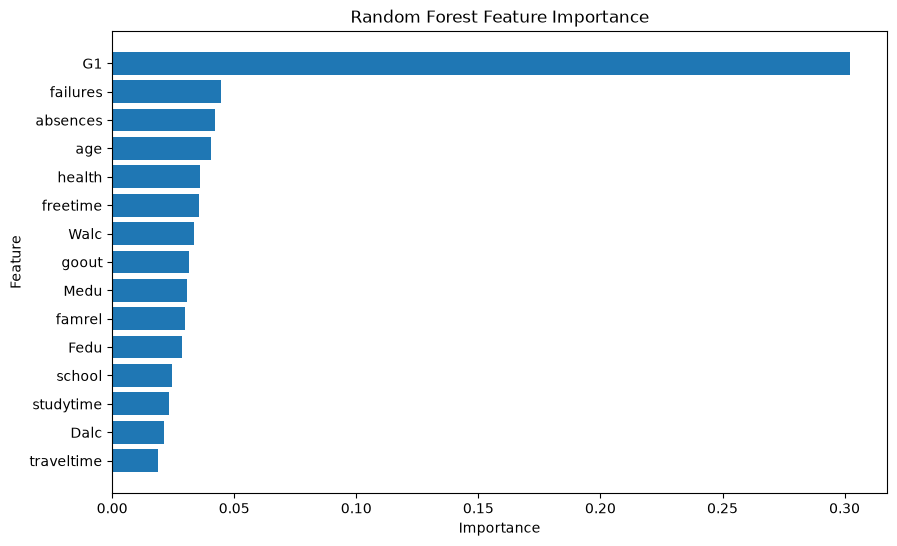

In [23]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [24]:
# Sort features from most important to least important
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Get feature names in importance order
ranked_features = feature_importance["Feature"].tolist()

print(ranked_features)

['G1', 'failures', 'absences', 'age', 'health', 'freetime', 'Walc', 'goout', 'Medu', 'famrel', 'Fedu', 'school', 'studytime', 'Dalc', 'traveltime', 'higher', 'romantic', 'famsize', 'sex', 'famsup', 'reason_reputation', 'Fjob_other', 'activities', 'guardian_mother', 'internet', 'Mjob_other', 'address', 'nursery', 'schoolsup', 'Fjob_services', 'Pstatus', 'Mjob_services', 'reason_home', 'Mjob_health', 'paid', 'reason_other', 'Mjob_teacher', 'Fjob_teacher', 'guardian_other', 'Fjob_health']


In [25]:
top_10_features = ranked_features[:10]
top_20_features = ranked_features[:20]
top_30_features = ranked_features[:30]

print("Top 10:", top_10_features)
print("Top 20:", top_20_features)
print("Top 30:", top_30_features)

Top 10: ['G1', 'failures', 'absences', 'age', 'health', 'freetime', 'Walc', 'goout', 'Medu', 'famrel']
Top 20: ['G1', 'failures', 'absences', 'age', 'health', 'freetime', 'Walc', 'goout', 'Medu', 'famrel', 'Fedu', 'school', 'studytime', 'Dalc', 'traveltime', 'higher', 'romantic', 'famsize', 'sex', 'famsup']
Top 30: ['G1', 'failures', 'absences', 'age', 'health', 'freetime', 'Walc', 'goout', 'Medu', 'famrel', 'Fedu', 'school', 'studytime', 'Dalc', 'traveltime', 'higher', 'romantic', 'famsize', 'sex', 'famsup', 'reason_reputation', 'Fjob_other', 'activities', 'guardian_mother', 'internet', 'Mjob_other', 'address', 'nursery', 'schoolsup', 'Fjob_services']


In [26]:
X_train_top10 = X_train_processed[top_10_features]
X_val_top10 = X_val_processed[top_10_features]
X_test_top10 = X_test_processed[top_10_features]

X_train_top20 = X_train_processed[top_20_features]
X_val_top20 = X_val_processed[top_20_features]
X_test_top20 = X_test_processed[top_20_features]

X_train_top30 = X_train_processed[top_30_features]
X_val_top30 = X_val_processed[top_30_features]
X_test_top30 = X_test_processed[top_30_features]


In [27]:
rf_top10 = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE
)

rf_top10.fit(X_train_top10, y_train)

y_val_pred_top10 = rf_top10.predict(X_val_top10)


rf_top20 = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE
)

rf_top20.fit(X_train_top20, y_train)

y_val_pred_top20 = rf_top20.predict(X_val_top20)


rf_top30 = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE
)

rf_top30.fit(X_train_top30, y_train)

y_val_pred_top30 = rf_top30.predict(X_val_top30)

In [28]:
# Top 10 metrics
top10_accuracy = accuracy_score(
    y_val,
    y_val_pred_top10
)

top10_macro_f1 = f1_score(
    y_val,
    y_val_pred_top10,
    average="macro"
)


# Top 20 metrics
top20_accuracy = accuracy_score(
    y_val,
    y_val_pred_top20
)

top20_macro_f1 = f1_score(
    y_val,
    y_val_pred_top20,
    average="macro"
)


# Top 30 metrics
top30_accuracy = accuracy_score(
    y_val,
    y_val_pred_top30
)

top30_macro_f1 = f1_score(
    y_val,
    y_val_pred_top30,
    average="macro"
)

In [29]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline RF - All Features",
        "RF - Top 30 Features",
        "RF - Top 20 Features",
        "RF - Top 10 Features"
    ],
    "Accuracy": [
        baseline_val_accuracy,
        top30_accuracy,
        top20_accuracy,
        top10_accuracy
    ],
    "Macro F1": [
        baseline_val_macro_f1,
        top30_macro_f1,
        top20_macro_f1,
        top10_macro_f1
    ]
})

comparison.sort_values(
    by="Macro F1",
    ascending=False
)

,Model,Accuracy,Macro F1
3,RF - Top 10 Features,0.845361,0.804645
1,RF - Top 30 Features,0.824742,0.779753
2,RF - Top 20 Features,0.804124,0.750776
0,Baseline RF - All Features,0.783505,0.696135


In [30]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid_search.fit(X_train_top10, y_train)

best_model = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Macro F1:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}

Best Cross Validation Macro F1:
0.7585251256901067


In [31]:
best_model = grid_search.best_estimator_

y_val_pred_tuned = best_model.predict(X_val_top10)

tuned_val_accuracy = accuracy_score(
    y_val,
    y_val_pred_tuned
)

tuned_val_macro_f1 = f1_score(
    y_val,
    y_val_pred_tuned,
    average="macro"
)

print("Tuned Validation Accuracy:", tuned_val_accuracy)
print("Tuned Validation Macro F1:", tuned_val_macro_f1)

Tuned Validation Accuracy: 0.845360824742268
Tuned Validation Macro F1: 0.8046451183946083


In [32]:
print("Features used to train model:")
print(best_model.feature_names_in_)
print("Number:", len(best_model.feature_names_in_))

print("\nFeatures in X_test_processed:")
print(X_test_processed.columns.tolist())
print("Number:", len(X_test_processed.columns))


print("Missing from test:")
print(set(best_model.feature_names_in_) - set(X_test_processed.columns))

print("\nExtra in test:")
print(set(X_test_processed.columns) - set(best_model.feature_names_in_))


Features used to train model:
['G1' 'failures' 'absences' 'age' 'health' 'freetime' 'Walc' 'goout'
 'Medu' 'famrel']
Number: 10

Features in X_test_processed:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher', 'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher', 'reason_home', 'reason_other', 'reason_reputation', 'guardian_mother', 'guardian_other', 'age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1']
Number: 40
Missing from test:
set()

Extra in test:
{'Pstatus', 'address', 'internet', 'higher', 'studytime', 'nursery', 'Fjob_teacher', 'Mjob_teacher', 'school', 'famsize', 'famsup', 'Mjob_health', 'reason_other', 'traveltime', 'Fjob_services', 'guardian_mother', 'guardian_other', 'Fjob_other', 'Mjob_other', 'paid', 'Mjob_services', 'reason_home',

In [33]:
tuned_test_pred = best_model.predict(X_test_top10)

tuned_test_accuracy = accuracy_score(
    y_test,
    tuned_test_pred
)

tuned_test_macro_f1 = f1_score(
    y_test,
    tuned_test_pred,
    average="macro"
)

In [34]:
# Final Test Evaluation

tuned_test_pred = best_model.predict(X_test_top10)

final_accuracy = accuracy_score(
    y_test,
    tuned_test_pred
)

final_macro_f1 = f1_score(
    y_test,
    tuned_test_pred,
    average="macro"
)

final_precision = precision_score(
    y_test,
    tuned_test_pred,
    average="weighted"
)

final_recall = recall_score(
    y_test,
    tuned_test_pred,
    average="weighted"
)

final_f1 = f1_score(
    y_test,
    tuned_test_pred,
    average="weighted"
)



print("Final Test Accuracy:", final_accuracy)
print("Final Test Macro F1:", final_macro_f1)
print("Final Test Precision:", final_precision)
print("Final Test Recall:", final_recall)
print("Final Test F1:", final_f1)


Final Test Accuracy: 0.8061224489795918
Final Test Macro F1: 0.709809936880708
Final Test Precision: 0.7995380584666298
Final Test Recall: 0.8061224489795918
Final Test F1: 0.7903181583645835


In [35]:
print("\nClassification Report:")
print(classification_report(y_test, tuned_test_pred))


Classification Report:
              precision    recall  f1-score   support

        High       0.62      0.33      0.43        15
         Low       0.94      0.75      0.83        20
      Medium       0.80      0.94      0.86        63

    accuracy                           0.81        98
   macro avg       0.79      0.67      0.71        98
weighted avg       0.80      0.81      0.79        98



In [42]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, tuned_test_pred, labels=["Low", "Medium", "High"]))




Confusion Matrix:
[[15  5  0]
 [ 1 59  3]
 [ 0 10  5]]


<Figure size 600x500 with 0 Axes>

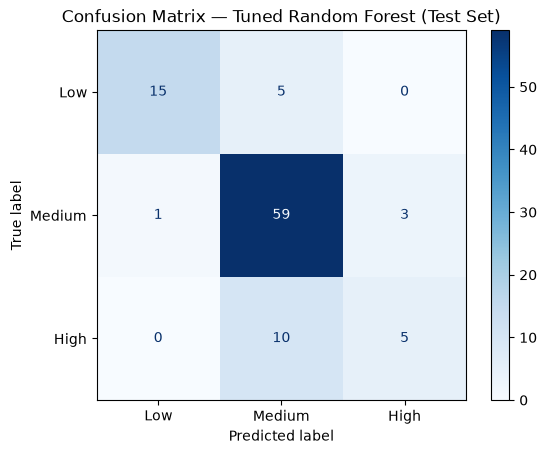

In [37]:
# Confusion Matrix Visualization
cm = confusion_matrix(y_test, tuned_test_pred, labels=["Low","Medium","High"])

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low","Medium","High"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — Tuned Random Forest (Test Set)")
plt.show()

In [38]:
comparison = pd.DataFrame({
    "Model": ["Sprint 1 Random Forest", "Sprint 2 Tuned Random Forest"],
    "Accuracy": [baseline_val_accuracy, tuned_test_accuracy],
    "Macro F1": [baseline_val_macro_f1, tuned_test_macro_f1]
})

comparison

,Model,Accuracy,Macro F1
0,Sprint 1 Random Forest,0.783505,0.696135
1,Sprint 2 Tuned Random Forest,0.806122,0.709810


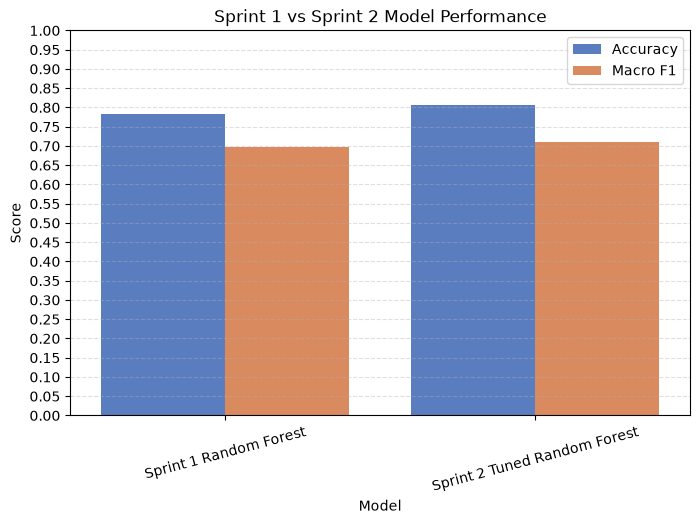

In [39]:
# Visualizing the comparison of model performance between Sprint 1 and Sprint 2
comparison_plot = comparison.melt(id_vars="Model", value_vars=["Accuracy", "Macro F1"],
                                    var_name="Metric", value_name="Score")

plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_plot, x="Model", y="Score", hue="Metric", palette="muted")
plt.title("Sprint 1 vs Sprint 2 Model Performance")
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.05, 0.05))
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.xticks(rotation=15)
plt.legend(title="")
plt.show()

In [40]:
joblib.dump(best_model, "student_risk_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [41]:
y_val_pred = best_model.predict(X_val_top10)

validation_accuracy = accuracy_score(y_val, y_val_pred)

print("Validation Accuracy:", validation_accuracy)

Validation Accuracy: 0.845360824742268
